Кластеризация латентных представлений для типизации режимов скважин

Цель:
1. Загрузить лучшие автоэнкодеры (GRU, TCN, Hybrid) для каждого типа скважины.
2. Построить latent vectors на полном наборе окон.
3. Для каждой архитектуры программно подобрать число кластеров K-Means.
4. Выбрать лучшую архитектуру по качеству кластеризации latent-space.
5. Для лучшей архитектуры получить финальные кластеры, типовые профили и thresholds.

Входные данные:
- models/{ecn,shgn}/{gru,tcn,hybrid}/model.pth
- data/processed/X_{ecn,shgn}_{train,val,test}.npy
- data/processed/window_sizes.json

Выходные данные:
- models/{ecn,shgn}/kmeans.pkl
- models/{ecn,shgn}/thresholds.pkl
- models/{ecn,shgn}/best_clustering_model.json

In [1]:
import copy
import importlib.util
import json
import logging
import pickle
from collections.abc import Callable
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib.axes import Axes
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

try:
    from umap import UMAP
except ImportError:
    UMAP = None

type Checkpoint = dict[str, Any]
type Bundle = dict[str, Any]
type ClusterProfiles = dict[int, dict[str, Any]]

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision("high")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,
)
LOGGER = logging.getLogger("clustering")

In [3]:
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

ARCHITECTURES = ["GRU", "TCN", "Hybrid"]
FEATURE_COLUMNS = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

PUMP_CONFIG: dict[str, dict[str, Any]] = {
    "ecn": {
        "title": "ЭЦН",
        "k_range": range(2, 10),
        "min_cluster_share_threshold": 0.03,
    },
    "shgn": {
        "title": "ШГН",
        "k_range": range(2, 10),
        "min_cluster_share_threshold": 0.03,
    },
}

plt.rcParams.update(
    {
        "figure.figsize": (14, 5),
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
    }
)

LOGGER.info("DEVICE: %s", DEVICE)
LOGGER.info("ARCHITECTURES: %s", ARCHITECTURES)
LOGGER.info("FEATURES: %d", len(FEATURE_COLUMNS))

2026-05-13 20:32:16,378 | INFO | DEVICE: cuda
2026-05-13 20:32:16,380 | INFO | ARCHITECTURES: ['GRU', 'TCN', 'Hybrid']
2026-05-13 20:32:16,382 | INFO | FEATURES: 9


In [4]:
def save_pickle(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as file_obj:
        pickle.dump(obj, file_obj)


def save_json(path: Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as file_obj:
        json.dump(obj, file_obj, ensure_ascii=False, indent=2)


def load_window_sizes() -> dict[str, int]:
    with open(DATA_DIR / "window_sizes.json", encoding="utf-8") as file_obj:
        window_sizes = json.load(file_obj)
    return {str(key): int(value) for key, value in window_sizes.items()}


WINDOW_SIZES = load_window_sizes()

In [5]:
def make_windows(array: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if len(array) < window_size:
        return np.empty((0, window_size, array.shape[1]), dtype=np.float32)

    windows = sliding_window_view(array, window_shape=window_size, axis=0)[::stride]
    windows = np.transpose(windows, (0, 2, 1)).astype(np.float32)
    return windows

def load_bundle(prefix: str, stride: int) -> Bundle:
    window_size = int(WINDOW_SIZES[prefix])

    parts: list[np.ndarray] = []
    split_sizes: dict[str, int] = {}

    for split in ("train", "val", "test"):
        path = DATA_DIR / f"X_{prefix}_{split}.npy"
        array = np.load(path).astype(np.float32)
        windows = make_windows(array, window_size=window_size, stride=stride)
        split_sizes[split] = int(len(windows))
        if len(windows) > 0:
            parts.append(windows)

    if not parts:
        raise ValueError(f"No windows were created for prefix={prefix}")

    x_all = np.concatenate(parts, axis=0).astype(np.float32)

    return {
        "prefix": prefix,
        "title": str(PUMP_CONFIG[prefix]["title"]),
        "window_size": window_size,
        "stride": stride,
        "X": x_all,
        "split_sizes": split_sizes,
    }

In [6]:
def load_build_model() -> Callable[..., nn.Module]:
    candidate_paths = [
        MODELS_DIR / "models.py",
        MODELS_DIR / "models" / "__init__.py",
    ]

    module_path: Path | None = None
    for path in candidate_paths:
        if path.exists():
            module_path = path
            break

    if module_path is None:
        raise FileNotFoundError("Не найден build_model в ../models")

    spec = importlib.util.spec_from_file_location("project_models", module_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Не удалось создать spec для {module_path}")

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    build_model = getattr(module, "build_model", None)
    if not callable(build_model):
        raise AttributeError("В модуле models нет callable build_model")

    return cast(Callable[..., nn.Module], build_model)


BUILD_MODEL = load_build_model()

In [7]:
def load_checkpoint(prefix: str, architecture: str) -> Checkpoint:
    checkpoint_path = MODELS_DIR / prefix / architecture.lower() / "model.pth"
    checkpoint = cast(
        Checkpoint,
        torch.load(checkpoint_path, map_location=DEVICE, weights_only=False),
    )
    return checkpoint


def get_stride_from_checkpoint(checkpoint: Checkpoint) -> int:
    cfg = cast(dict[str, Any], checkpoint["config"])
    return int(cfg["train_stride"])


def build_model_from_checkpoint(checkpoint: Checkpoint) -> nn.Module:
    cfg = cast(dict[str, Any], checkpoint["config"])

    model = BUILD_MODEL(
        str(checkpoint["architecture"]),
        int(cfg["input_dim"]),
        int(cfg["hidden_size"]),
        int(checkpoint["latent_dim"]),
        int(cfg["num_layers"]),
        int(cfg["kernel_size"]),
        int(cfg["dilation_base"]),
        float(cfg["dropout"]),
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [8]:
def encode_batch(model: nn.Module, batch: torch.Tensor) -> torch.Tensor:
    encoder_attr = getattr(model, "encode", None)

    if callable(encoder_attr):
        encoder_fn = cast(Callable[[torch.Tensor], torch.Tensor], encoder_attr)
        return encoder_fn(batch)

    forward_fn = cast(Callable[[torch.Tensor], Any], model.forward)
    output = forward_fn(batch)

    if not isinstance(output, tuple) or len(output) < 2:
        raise TypeError("Model forward(batch) must return tuple (_, z).")

    z_candidate = output[1]
    if not isinstance(z_candidate, torch.Tensor):
        raise TypeError("Latent output z must be torch.Tensor.")

    return z_candidate


def encode_dataset(
    model: nn.Module,
    x_data: np.ndarray,
    batch_size: int = 1024,
) -> np.ndarray:
    latent_parts: list[np.ndarray] = []

    with torch.no_grad():
        for start in range(0, len(x_data), batch_size):
            stop = min(start + batch_size, len(x_data))
            batch = torch.from_numpy(x_data[start:stop]).float().to(DEVICE)
            z_tensor = encode_batch(model, batch)
            latent_parts.append(z_tensor.detach().cpu().numpy())

    z_all = np.concatenate(latent_parts, axis=0).astype(np.float32)
    return z_all

In [9]:
def compute_cluster_metrics(z_data: np.ndarray, labels: np.ndarray) -> dict[str, float]:
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        raise ValueError("Для расчета метрик требуется минимум 2 кластера.")

    silhouette = float(
        silhouette_score(
            z_data,
            labels,
            sample_size=min(8000, len(z_data)),
            random_state=SEED,
        )
    )
    davies_bouldin = float(davies_bouldin_score(z_data, labels))
    calinski_harabasz = float(calinski_harabasz_score(z_data, labels))

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
    }


def find_best_kmeans_for_z(
    z_data: np.ndarray,
    k_range: range,
    min_cluster_share_threshold: float,
    n_init: int = 20,
) -> tuple[KMeans, np.ndarray, pd.DataFrame, pd.Series]:
    rows: list[dict[str, Any]] = []
    fitted_models: dict[int, tuple[KMeans, np.ndarray]] = {}

    for k in k_range:
        kmeans = KMeans(n_clusters=int(k), random_state=SEED, n_init=n_init)
        labels = kmeans.fit_predict(z_data)

        counts = np.bincount(labels)
        min_cluster_size = int(counts.min())
        min_cluster_share = float(min_cluster_size / len(labels))
        valid_by_size = bool(min_cluster_share >= min_cluster_share_threshold)

        metrics = compute_cluster_metrics(z_data, labels)

        rows.append(
            {
                "k": int(k),
                "silhouette": float(metrics["silhouette"]),
                "davies_bouldin": float(metrics["davies_bouldin"]),
                "calinski_harabasz": float(metrics["calinski_harabasz"]),
                "inertia": float(kmeans.inertia_),
                "min_cluster_size": min_cluster_size,
                "min_cluster_share": min_cluster_share,
                "valid_by_size": valid_by_size,
            }
        )

        fitted_models[int(k)] = (kmeans, labels)

    k_search_df = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

    valid_df = k_search_df[k_search_df["valid_by_size"]].copy()
    if valid_df.empty:
        valid_df = k_search_df.copy()

    selected_row = valid_df.sort_values(
        by=["silhouette", "davies_bouldin", "calinski_harabasz"],
        ascending=[False, True, False],
    ).iloc[0]

    best_k = int(selected_row["k"])
    best_kmeans, best_labels = fitted_models[best_k]

    return best_kmeans, best_labels, k_search_df, selected_row

In [10]:
def evaluate_architectures(
    prefix: str,
) -> tuple[
    Bundle,
    pd.DataFrame,
    dict[str, np.ndarray],
    dict[str, Checkpoint],
    dict[str, KMeans],
    dict[str, np.ndarray],
    dict[str, pd.DataFrame],
]:
    k_range = cast(range, PUMP_CONFIG[prefix]["k_range"])
    min_cluster_share_threshold = float(PUMP_CONFIG[prefix]["min_cluster_share_threshold"])

    rows: list[dict[str, Any]] = []
    latents: dict[str, np.ndarray] = {}
    checkpoints: dict[str, Checkpoint] = {}
    best_kmeans_by_arch: dict[str, KMeans] = {}
    best_labels_by_arch: dict[str, np.ndarray] = {}
    k_search_by_arch: dict[str, pd.DataFrame] = {}

    base_checkpoint = load_checkpoint(prefix, ARCHITECTURES[0])
    stride = get_stride_from_checkpoint(base_checkpoint)
    bundle = load_bundle(prefix, stride=stride)

    for architecture in ARCHITECTURES:
        checkpoint = base_checkpoint if architecture == ARCHITECTURES[0] else load_checkpoint(prefix, architecture)
        model = build_model_from_checkpoint(checkpoint)
        z_data = encode_dataset(model, cast(np.ndarray, bundle["X"]))

        kmeans, labels, k_search_df, selected_row = find_best_kmeans_for_z(
            z_data=z_data,
            k_range=k_range,
            min_cluster_share_threshold=min_cluster_share_threshold,
        )

        rows.append(
            {
                "pump_type": prefix,
                "architecture": architecture,
                "latent_dim": int(checkpoint["latent_dim"]),
                "val_loss": float(checkpoint["metrics"]["val_loss"]),
                "test_loss": (
                    float(checkpoint["metrics"]["test_loss"])
                    if checkpoint["metrics"]["test_loss"] is not None
                    else np.nan
                ),
                "best_k": int(selected_row["k"]),
                "silhouette": float(selected_row["silhouette"]),
                "davies_bouldin": float(selected_row["davies_bouldin"]),
                "calinski_harabasz": float(selected_row["calinski_harabasz"]),
                "min_cluster_size": int(selected_row["min_cluster_size"]),
                "min_cluster_share": float(selected_row["min_cluster_share"]),
                "valid_by_size": bool(selected_row["valid_by_size"]),
            }
        )

        latents[architecture] = z_data
        checkpoints[architecture] = checkpoint
        best_kmeans_by_arch[architecture] = kmeans
        best_labels_by_arch[architecture] = labels
        k_search_by_arch[architecture] = k_search_df

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    candidate_df = pd.DataFrame(rows).reset_index(drop=True)

    return (
        bundle,
        candidate_df,
        latents,
        checkpoints,
        best_kmeans_by_arch,
        best_labels_by_arch,
        k_search_by_arch,
    )

In [11]:
def choose_best_architecture(candidate_df: pd.DataFrame) -> pd.Series:
    valid_df = candidate_df[candidate_df["valid_by_size"]].copy()
    if valid_df.empty:
        valid_df = candidate_df.copy()

    return valid_df.sort_values(
        by=["silhouette", "davies_bouldin", "val_loss", "calinski_harabasz"],
        ascending=[False, True, True, False],
    ).iloc[0]

In [12]:
def reduce_pca(z_data: np.ndarray, n_components: int) -> tuple[np.ndarray, float]:
    reducer = PCA(n_components=n_components, random_state=SEED)
    z_reduced = reducer.fit_transform(z_data).astype(np.float32)
    explained = float(reducer.explained_variance_ratio_.sum())
    return z_reduced, explained


def reduce_umap(z_data: np.ndarray, n_components: int) -> np.ndarray | None:
    if UMAP is None:
        return None

    reducer = UMAP(
        n_components=n_components,
        random_state=SEED,
        n_neighbors=30,
        min_dist=0.1,
    )
    z_reduced = reducer.fit_transform(z_data)
    return np.asarray(z_reduced, dtype=np.float32)

In [13]:
def plot_latent_space(
    z_data: np.ndarray,
    labels: np.ndarray,
    title: str,
    n_components: int = 2,
) -> None:
    if n_components not in (2, 3):
        raise ValueError("n_components must be 2 or 3")

    z_pca, explained = reduce_pca(z_data, n_components=n_components)
    z_umap = reduce_umap(z_data, n_components=n_components)

    layouts: list[tuple[np.ndarray, str]] = [(z_pca, f"PCA {n_components}D ({explained:.1%})")]
    if z_umap is not None:
        layouts.append((z_umap, f"UMAP {n_components}D"))

    palette = [
        "#2E86AB",
        "#A23B72",
        "#F18F01",
        "#4CAF50",
        "#7B61FF",
        "#009688",
        "#D81B60",
        "#6D4C41",
    ]

    if n_components == 2:
        fig, axes_obj = plt.subplots(1, len(layouts), figsize=(7 * len(layouts), 5))
        axes_list = [cast(Axes, ax) for ax in np.atleast_1d(axes_obj).ravel()]

        for ax, (z_reduced, name) in zip(axes_list, layouts, strict=True):
            for cluster_id in sorted(np.unique(labels)):
                mask = labels == cluster_id
                ax.scatter(
                    z_reduced[mask, 0],
                    z_reduced[mask, 1],
                    s=6,
                    alpha=0.45,
                    color=palette[int(cluster_id) % len(palette)],
                    label=f"cluster {cluster_id} (n={int(mask.sum())})",
                    rasterized=True,
                )
            ax.set_title(name)
            ax.set_xlabel("component 1")
            ax.set_ylabel("component 2")
            ax.legend(fontsize=8, markerscale=3)

        fig.suptitle(title, fontweight="bold")
        plt.tight_layout()
        plt.show()
        plt.close(fig)
        return

    fig = plt.figure(figsize=(8 * len(layouts), 6))

    for idx, (z_reduced, name) in enumerate(layouts, start=1):
        ax = cast(Axes, fig.add_subplot(1, len(layouts), idx, projection="3d"))
        for cluster_id in sorted(np.unique(labels)):
            mask = labels == cluster_id
            ax.scatter(
                z_reduced[mask, 0],
                z_reduced[mask, 1],
                z_reduced[mask, 2],
                s=8,
                alpha=0.45,
                color=palette[int(cluster_id) % len(palette)],
                label=f"cluster {cluster_id} (n={int(mask.sum())})",
                depthshade=True,
            )
        ax.set_title(name)
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.set_zlabel("component 3")
        ax.legend(fontsize=8, markerscale=2)

    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [14]:
def plot_k_search(k_search_df: pd.DataFrame, title: str) -> None:
    fig, axes_obj = plt.subplots(1, 4, figsize=(18, 4))
    axes_list = [cast(Axes, ax) for ax in np.atleast_1d(axes_obj).ravel()]

    axes_list[0].plot(k_search_df["k"], k_search_df["silhouette"], marker="o", color="#2E86AB")
    axes_list[0].set_title("Silhouette")
    axes_list[0].set_xlabel("k")

    axes_list[1].plot(k_search_df["k"], k_search_df["davies_bouldin"], marker="o", color="#A23B72")
    axes_list[1].set_title("Davies-Bouldin")
    axes_list[1].set_xlabel("k")

    axes_list[2].plot(k_search_df["k"], k_search_df["calinski_harabasz"], marker="o", color="#F18F01")
    axes_list[2].set_title("Calinski-Harabasz")
    axes_list[2].set_xlabel("k")

    axes_list[3].plot(k_search_df["k"], k_search_df["min_cluster_share"], marker="o", color="#4CAF50")
    axes_list[3].set_title("Min cluster share")
    axes_list[3].set_xlabel("k")

    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [15]:
def build_cluster_profiles(
    z_data: np.ndarray,
    x_data: np.ndarray,
    kmeans: KMeans,
    labels: np.ndarray,
) -> tuple[ClusterProfiles, pd.DataFrame]:
    profiles: ClusterProfiles = {}
    rows: list[dict[str, Any]] = []

    for cluster_id in range(kmeans.n_clusters):
        mask = labels == cluster_id
        cluster_size = int(mask.sum())
        centroid = np.asarray(kmeans.cluster_centers_[cluster_id], dtype=np.float32)

        z_cluster = z_data[mask]
        x_cluster = x_data[mask]

        distances = np.linalg.norm(z_cluster - centroid, axis=1)
        mean_profile = np.asarray(x_cluster.mean(axis=0), dtype=np.float32)
        std_profile = np.asarray(x_cluster.std(axis=0), dtype=np.float32)

        global_level = float(mean_profile.mean())
        temporal_volatility = float(std_profile.mean())
        centroid_norm = float(np.linalg.norm(centroid))

        profiles[cluster_id] = {
            "cluster_id": int(cluster_id),
            "n_cluster_windows": cluster_size,
            "n_profile_windows": cluster_size,
            "mean_profile": mean_profile,
            "std_profile": std_profile,
            "global_level": global_level,
            "temporal_volatility": temporal_volatility,
            "centroid": centroid,
            "centroid_norm": centroid_norm,
            "distance_mean": float(distances.mean()),
            "distance_std": float(distances.std()),
        }

        rows.append(
            {
                "cluster_id": int(cluster_id),
                "n_cluster_windows": cluster_size,
                "n_profile_windows": cluster_size,
                "global_level": global_level,
                "temporal_volatility": temporal_volatility,
                "centroid_norm": centroid_norm,
                "distance_mean": float(distances.mean()),
                "distance_std": float(distances.std()),
            }
        )

    stats_df = pd.DataFrame(rows).sort_values("cluster_id").reset_index(drop=True)
    return profiles, stats_df


def derive_cluster_order(profile_stats_df: pd.DataFrame) -> list[int]:
    ordered = (
        profile_stats_df.sort_values(
            by=["global_level", "temporal_volatility", "centroid_norm", "cluster_id"],
            ascending=[True, True, True, True],
        )["cluster_id"]
        .astype(int)
        .tolist()
    )
    return ordered

In [16]:
def remap_labels(labels: np.ndarray, order: list[int]) -> np.ndarray:
    mapping = {old_id: new_id for new_id, old_id in enumerate(order)}
    return np.array([mapping[int(label)] for label in labels], dtype=np.int64)


def reorder_kmeans_and_profiles(
    kmeans: KMeans,
    labels: np.ndarray,
    profiles: ClusterProfiles,
    profile_stats_df: pd.DataFrame,
    order: list[int],
) -> tuple[KMeans, np.ndarray, ClusterProfiles, pd.DataFrame]:
    if sorted(order) != list(range(kmeans.n_clusters)):
        raise ValueError("Некорректный порядок кластеров.")

    new_kmeans = copy.deepcopy(kmeans)
    new_kmeans.cluster_centers_ = new_kmeans.cluster_centers_[order].copy()

    new_labels = remap_labels(labels, order)
    mapping = {old_id: new_id for new_id, old_id in enumerate(order)}

    new_profiles: ClusterProfiles = {}
    for old_id, payload in profiles.items():
        new_id = mapping[int(old_id)]
        new_payload = dict(payload)
        new_payload["cluster_id"] = int(new_id)
        new_profiles[new_id] = new_payload

    new_profile_stats_df = profile_stats_df.copy()
    new_profile_stats_df["cluster_id"] = new_profile_stats_df["cluster_id"].map(mapping)
    new_profile_stats_df = new_profile_stats_df.sort_values("cluster_id").reset_index(drop=True)

    return new_kmeans, new_labels, new_profiles, new_profile_stats_df

In [17]:
def plot_cluster_profiles(profiles: ClusterProfiles, title: str) -> None:
    cluster_ids = sorted(profiles.keys())
    sample_profile = np.asarray(profiles[cluster_ids[0]]["mean_profile"], dtype=np.float32)
    window_size = int(sample_profile.shape[0])
    steps = np.arange(window_size)

    fig, axes_obj = plt.subplots(
        len(cluster_ids),
        len(FEATURE_COLUMNS),
        figsize=(2.6 * len(FEATURE_COLUMNS), 3.1 * len(cluster_ids)),
        squeeze=False,
    )
    axes_matrix = np.asarray(axes_obj)

    palette = [
        "#2E86AB",
        "#A23B72",
        "#F18F01",
        "#4CAF50",
        "#7B61FF",
        "#009688",
        "#D81B60",
        "#6D4C41",
    ]

    for row_idx, cluster_id in enumerate(cluster_ids):
        payload = profiles[cluster_id]
        mean_profile = np.asarray(payload["mean_profile"], dtype=np.float32)
        std_profile = np.asarray(payload["std_profile"], dtype=np.float32)
        color = palette[row_idx % len(palette)]

        for feature_idx, feature_name in enumerate(FEATURE_COLUMNS):
            ax = cast(Axes, axes_matrix[row_idx, feature_idx])
            ax.plot(steps, mean_profile[:, feature_idx], color=color, linewidth=1.7)
            ax.fill_between(
                steps,
                mean_profile[:, feature_idx] - std_profile[:, feature_idx],
                mean_profile[:, feature_idx] + std_profile[:, feature_idx],
                color=color,
                alpha=0.25,
            )

            if row_idx == 0:
                ax.set_title(feature_name, fontsize=9, fontweight="bold")
            if feature_idx == 0:
                ax.set_ylabel(f"Cluster {cluster_id}", fontsize=9, fontweight="bold")

            ax.tick_params(labelsize=7)

    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def compute_thresholds(
    z_data: np.ndarray,
    kmeans: KMeans,
    labels: np.ndarray,
    warn_percentile: float = 90.0,
    alert_percentile: float = 97.0,
) -> dict[int, dict[str, float]]:
    thresholds: dict[int, dict[str, float]] = {}

    for cluster_id in range(kmeans.n_clusters):
        mask = labels == cluster_id
        distances = np.linalg.norm(z_data[mask] - kmeans.cluster_centers_[cluster_id], axis=1)

        thresholds[cluster_id] = {
            "mean": float(distances.mean()),
            "std": float(distances.std()),
            "p50": float(np.percentile(distances, 50)),
            "warn": float(np.percentile(distances, warn_percentile)),
            "alert": float(np.percentile(distances, alert_percentile)),
        }

    return thresholds

In [18]:
def plot_threshold_histograms(
    z_data: np.ndarray,
    kmeans: KMeans,
    labels: np.ndarray,
    thresholds: dict[int, dict[str, float]],
    title: str,
) -> None:
    n_clusters = int(kmeans.n_clusters)
    fig, axes_obj = plt.subplots(1, n_clusters, figsize=(4.8 * n_clusters, 4), squeeze=False)
    axes_matrix = np.asarray(axes_obj)

    palette = [
        "#2E86AB",
        "#A23B72",
        "#F18F01",
        "#4CAF50",
        "#7B61FF",
        "#009688",
        "#D81B60",
        "#6D4C41",
    ]

    for cluster_id in range(n_clusters):
        ax = cast(Axes, axes_matrix[0, cluster_id])
        mask = labels == cluster_id
        distances = np.linalg.norm(z_data[mask] - kmeans.cluster_centers_[cluster_id], axis=1)

        ax.hist(distances, bins=40, color=palette[cluster_id % len(palette)], alpha=0.75)
        ax.axvline(thresholds[cluster_id]["p50"], color="#444", linestyle=":", linewidth=2, label="p50")
        ax.axvline(thresholds[cluster_id]["warn"], color="#F39C12", linestyle="--", linewidth=2, label="warn")
        ax.axvline(thresholds[cluster_id]["alert"], color="#E74C3C", linestyle="--", linewidth=2, label="alert")
        ax.set_title(f"Cluster {cluster_id}")
        ax.set_xlabel("Distance to centroid")
        ax.set_ylabel("Count")
        ax.legend()

    fig.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def summarize_clusters(
    profiles: ClusterProfiles,
    feature_columns: list[str],
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    cluster_ids = sorted(profiles.keys())
    global_levels = np.array([float(profiles[c]["global_level"]) for c in cluster_ids], dtype=float)
    temporal_vols = np.array([float(profiles[c]["temporal_volatility"]) for c in cluster_ids], dtype=float)

    if len(global_levels) > 1:
        level_q33, level_q66 = np.quantile(global_levels, [0.33, 0.66])
    else:
        level_q33 = float(global_levels[0])
        level_q66 = float(global_levels[0])

    vol_q50 = float(np.quantile(temporal_vols, 0.50))

    for cluster_id in cluster_ids:
        payload = profiles[cluster_id]
        mean_profile = np.asarray(payload["mean_profile"], dtype=np.float32)
        std_profile = np.asarray(payload["std_profile"], dtype=np.float32)

        feature_levels = mean_profile.mean(axis=0)
        feature_volatility = std_profile.mean(axis=0)

        top_pos_idx = np.argsort(feature_levels)[-3:][::-1]
        top_neg_idx = np.argsort(feature_levels)[:3]
        top_var_idx = np.argsort(feature_volatility)[-3:][::-1]

        global_level = float(payload["global_level"])
        temporal_volatility = float(payload["temporal_volatility"])

        if global_level <= level_q33:
            activity_level = "low"
        elif global_level >= level_q66:
            activity_level = "high"
        else:
            activity_level = "medium"

        stability_level = "variable" if temporal_volatility >= vol_q50 else "stable"
        signature = f"{activity_level}_{stability_level}"

        rows.append(
            {
                "cluster_id": int(cluster_id),
                "n_cluster_windows": int(payload["n_cluster_windows"]),
                "n_profile_windows": int(payload["n_profile_windows"]),
                "global_level": global_level,
                "temporal_volatility": temporal_volatility,
                "centroid_norm": float(payload["centroid_norm"]),
                "distance_mean": float(payload["distance_mean"]),
                "distance_std": float(payload["distance_std"]),
                "activity_level": activity_level,
                "stability_level": stability_level,
                "signature": signature,
                "top_positive_features": ", ".join(feature_columns[int(i)] for i in top_pos_idx),
                "top_negative_features": ", ".join(feature_columns[int(i)] for i in top_neg_idx),
                "top_variable_features": ", ".join(feature_columns[int(i)] for i in top_var_idx),
            }
        )

    summary_df = pd.DataFrame(rows).sort_values("cluster_id").reset_index(drop=True)
    return summary_df

In [19]:
def save_final_artifacts(
    bundle: Bundle,
    best_arch_row: pd.Series,
    checkpoint: Checkpoint,
    kmeans: KMeans,
    thresholds: dict[int, dict[str, float]],
    candidate_df: pd.DataFrame,
    cluster_summary_df: pd.DataFrame,
) -> None:
    prefix = str(bundle["prefix"])
    out_dir = MODELS_DIR / prefix
    out_dir.mkdir(parents=True, exist_ok=True)

    save_pickle(out_dir / "kmeans.pkl", kmeans)
    save_pickle(out_dir / "thresholds.pkl", thresholds)

    best_model_meta = {
        "pump_type": prefix,
        "architecture": str(best_arch_row["architecture"]),
        "latent_dim": int(checkpoint["latent_dim"]),
        "best_k": int(best_arch_row["best_k"]),
        "silhouette": float(best_arch_row["silhouette"]),
        "davies_bouldin": float(best_arch_row["davies_bouldin"]),
        "calinski_harabasz": float(best_arch_row["calinski_harabasz"]),
        "val_loss": float(best_arch_row["val_loss"]),
        "test_loss": None if pd.isna(best_arch_row["test_loss"]) else float(best_arch_row["test_loss"]),
        "window_size": int(bundle["window_size"]),
        "stride": int(bundle["stride"]),
        "feature_columns": FEATURE_COLUMNS,
        "split_sizes": cast(dict[str, int], bundle["split_sizes"]),
        "architecture_ranking": candidate_df.to_dict(orient="records"),
        "cluster_summary": cluster_summary_df.to_dict(orient="records"),
    }
    save_json(out_dir / "best_clustering_model.json", best_model_meta)

In [20]:
def run_clustering_pipeline(prefix: str) -> dict[str, Any]:
    LOGGER.info("Pipeline started for prefix=%s", prefix)

    (
        bundle,
        candidate_df,
        latents,
        checkpoints,
        best_kmeans_by_arch,
        best_labels_by_arch,
        k_search_by_arch,
    ) = evaluate_architectures(prefix)

    best_arch_row = choose_best_architecture(candidate_df)
    best_architecture = str(best_arch_row["architecture"])

    candidate_df = candidate_df.copy()
    candidate_df["selected"] = candidate_df["architecture"].eq(best_architecture)

    candidate_df = candidate_df.sort_values(
        by=[
            "selected",
            "valid_by_size",
            "best_k",
            "silhouette",
            "davies_bouldin",
            "val_loss",
            "calinski_harabasz",
        ],
        ascending=[False, False, True, False, True, True, False],
    ).reset_index(drop=True)

    print(candidate_df.to_string(index=False))
    print()

    z_data = latents[best_architecture]
    checkpoint = checkpoints[best_architecture]
    kmeans = best_kmeans_by_arch[best_architecture]
    labels = best_labels_by_arch[best_architecture]
    k_search_df = k_search_by_arch[best_architecture]

    plot_k_search(
        k_search_df=k_search_df,
        title=f"{bundle['title']} — поиск числа кластеров ({best_architecture})",
    )

    plot_latent_space(
        z_data=z_data,
        labels=labels,
        title=f"{bundle['title']} — latent space 2D ({best_architecture}, k={kmeans.n_clusters})",
        n_components=2,
    )

    plot_latent_space(
        z_data=z_data,
        labels=labels,
        title=f"{bundle['title']} — latent space 3D ({best_architecture}, k={kmeans.n_clusters})",
        n_components=3,
    )

    profiles, profile_stats_df = build_cluster_profiles(
        z_data=z_data,
        x_data=cast(np.ndarray, bundle["X"]),
        kmeans=kmeans,
        labels=labels,
    )

    cluster_order = derive_cluster_order(profile_stats_df)

    kmeans, labels, profiles, profile_stats_df = reorder_kmeans_and_profiles(
        kmeans=kmeans,
        labels=labels,
        profiles=profiles,
        profile_stats_df=profile_stats_df,
        order=cluster_order,
    )

    plot_cluster_profiles(
        profiles=profiles,
        title=f"{bundle['title']} — типовые профили кластеров",
    )

    thresholds = compute_thresholds(
        z_data=z_data,
        kmeans=kmeans,
        labels=labels,
    )

    plot_threshold_histograms(
        z_data=z_data,
        kmeans=kmeans,
        labels=labels,
        thresholds=thresholds,
        title=f"{bundle['title']} — распределения расстояний до центроидов",
    )

    cluster_summary_df = summarize_clusters(
        profiles=profiles,
        feature_columns=FEATURE_COLUMNS,
    )

    print(profile_stats_df.to_string(index=False))
    print()
    print(cluster_summary_df.to_string(index=False))
    print()

    save_final_artifacts(
        bundle=bundle,
        best_arch_row=best_arch_row,
        checkpoint=checkpoint,
        kmeans=kmeans,
        thresholds=thresholds,
        candidate_df=candidate_df,
        cluster_summary_df=cluster_summary_df,
    )

    result = {
        "prefix": prefix,
        "bundle": bundle,
        "candidate_df": candidate_df,
        "best_arch_row": best_arch_row,
        "best_architecture": best_architecture,
        "checkpoint": checkpoint,
        "z_data": z_data,
        "kmeans": kmeans,
        "labels": labels,
        "k_search_df": k_search_df,
        "profile_stats_df": profile_stats_df,
        "thresholds": thresholds,
        "cluster_summary_df": cluster_summary_df,
    }

    LOGGER.info("Pipeline finished for prefix=%s", prefix)
    return result

2026-05-13 20:32:16,862 | INFO | Pipeline started for prefix=ecn


pump_type architecture  latent_dim  val_loss  test_loss  best_k  silhouette  davies_bouldin  calinski_harabasz  min_cluster_size  min_cluster_share  valid_by_size  selected
      ecn       Hybrid           8  0.019335   0.018038       4    0.611955        0.503425        5766.971611               317           0.115905           True      True
      ecn          GRU           8  0.019786   0.018218       4    0.547745        0.639376        3837.875538               343           0.125411           True     False
      ecn          TCN           8  0.017755   0.016886       2    0.854363        0.167647        1821.425715                25           0.009141          False     False



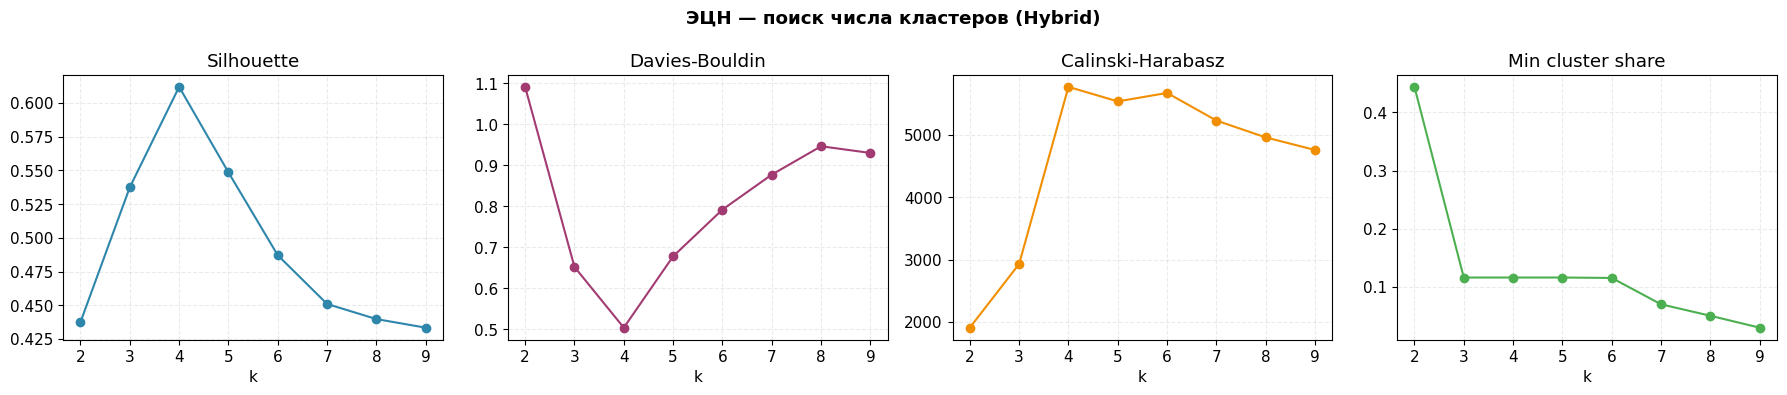

c:\Users\aslan\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


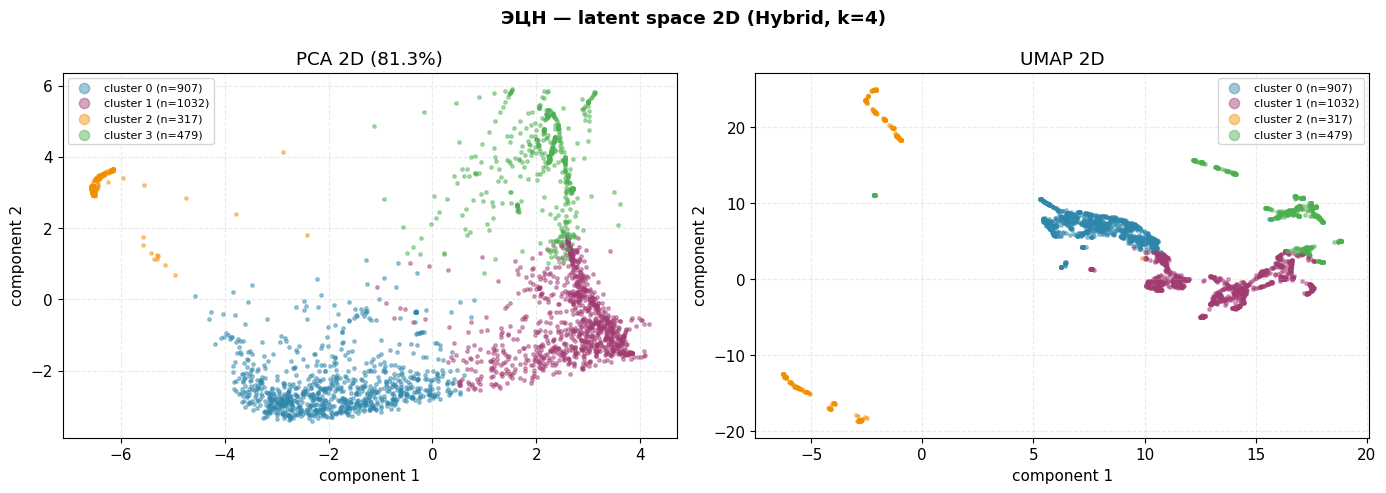

c:\Users\aslan\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


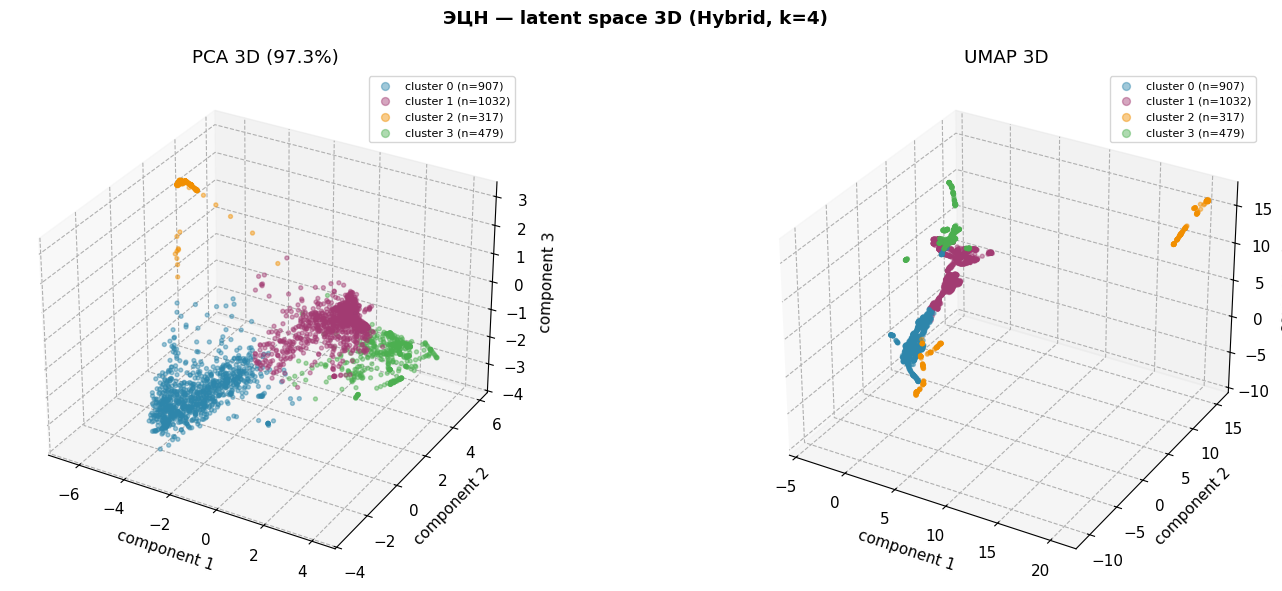

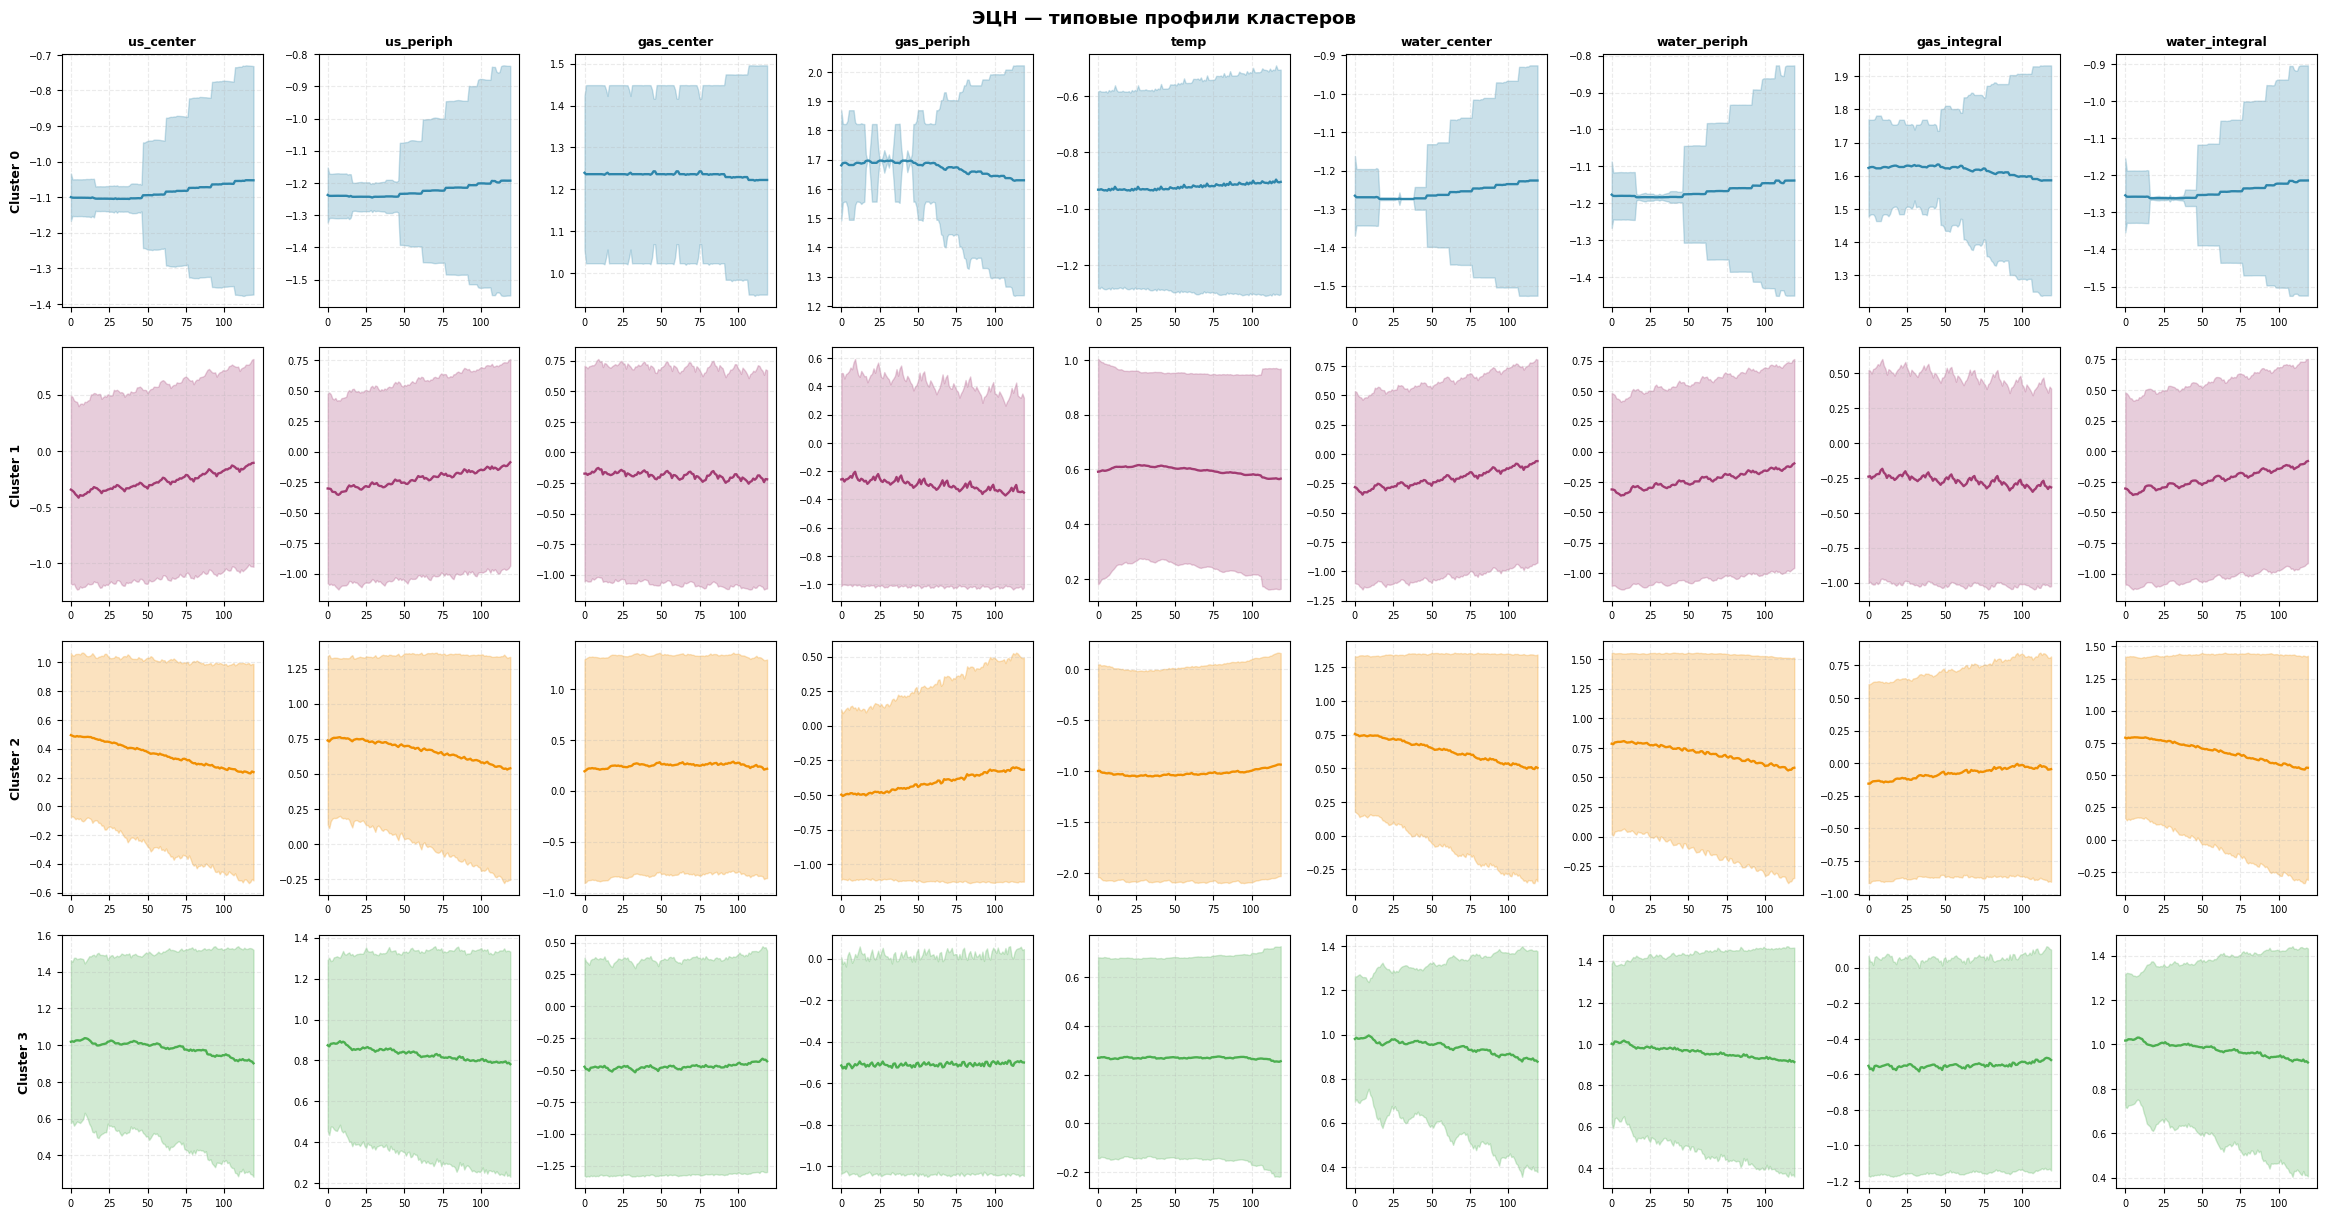

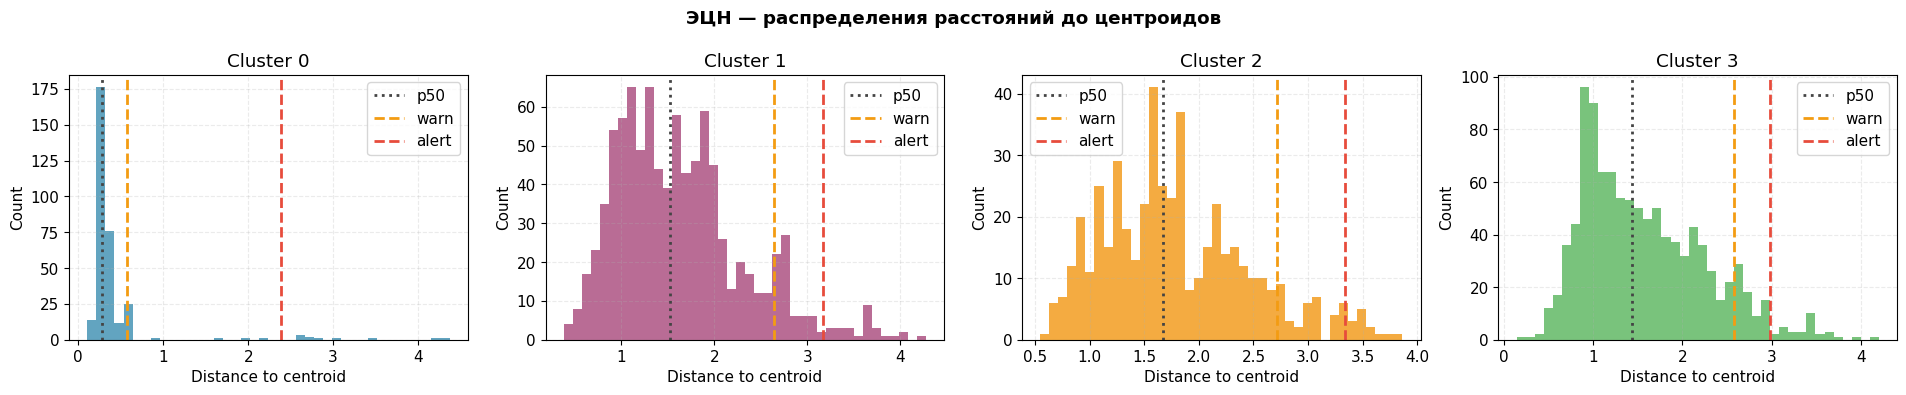

2026-05-13 20:34:23,934 | INFO | Pipeline finished for prefix=ecn


 cluster_id  n_cluster_windows  n_profile_windows  global_level  temporal_volatility  centroid_norm  distance_mean  distance_std
          0                317                317     -0.264271             0.199682       6.953747       0.416594      0.538499
          1                907                907     -0.146341             0.761250       2.580312       1.624724      0.681539
          2                479                479      0.198398             0.810558       6.159603       1.794786      0.672083
          3               1032               1032      0.381079             0.522357       4.192773       1.566644      0.684901

 cluster_id  n_cluster_windows  n_profile_windows  global_level  temporal_volatility  centroid_norm  distance_mean  distance_std activity_level stability_level       signature                   top_positive_features                   top_negative_features                top_variable_features
          0                317                317     -0.2642

In [21]:
ecn_result = run_clustering_pipeline("ecn")

2026-05-13 20:34:23,953 | INFO | Pipeline started for prefix=shgn


pump_type architecture  latent_dim  val_loss  test_loss  best_k  silhouette  davies_bouldin  calinski_harabasz  min_cluster_size  min_cluster_share  valid_by_size  selected
     shgn          GRU           8  0.182790   0.205540       4    0.939738        0.081537       1.109196e+06              4103           0.163949           True      True
     shgn          TCN          12  0.182503   0.201916       2    0.561557        0.440715       1.836289e+04              3003           0.119995           True     False
     shgn       Hybrid           4  0.182069   0.203513       4    0.639283        0.464034       6.752344e+04              3004           0.120035           True     False



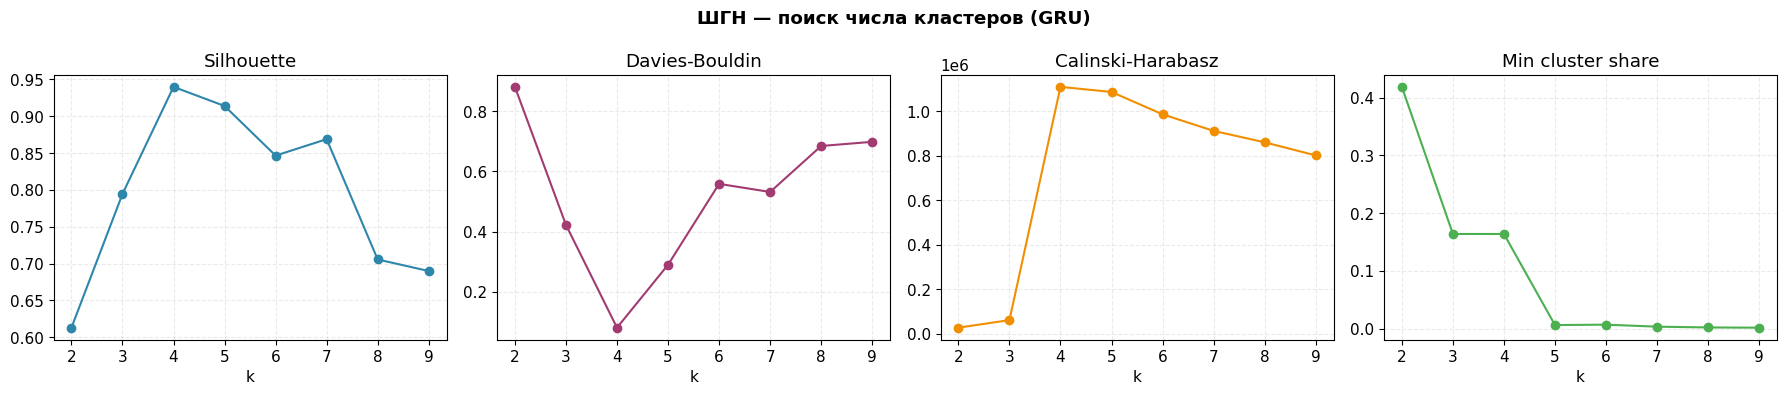

c:\Users\aslan\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


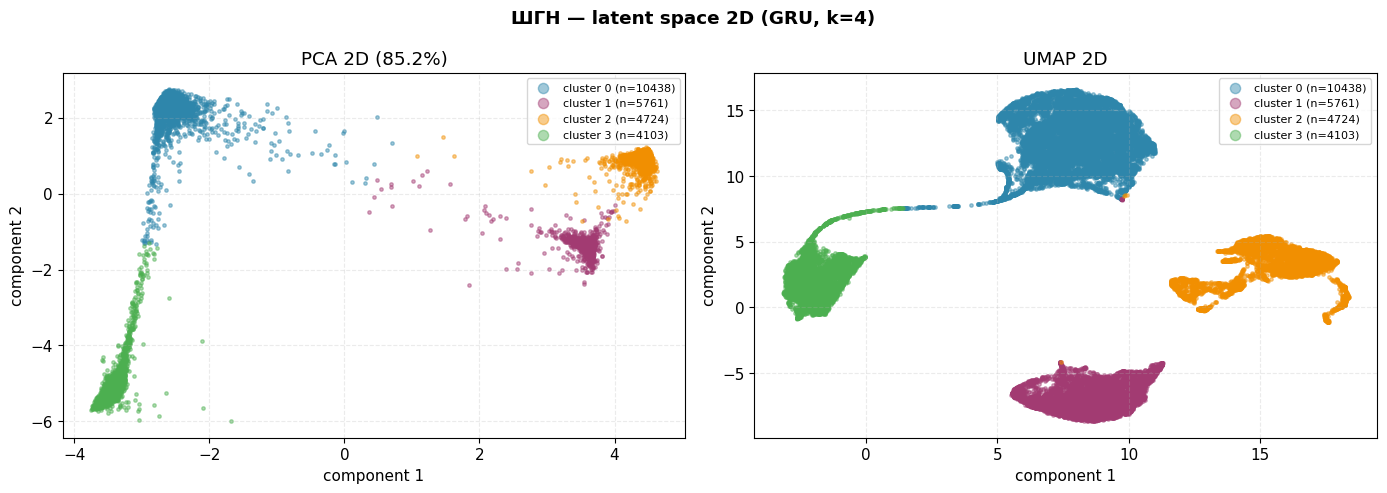

c:\Users\aslan\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


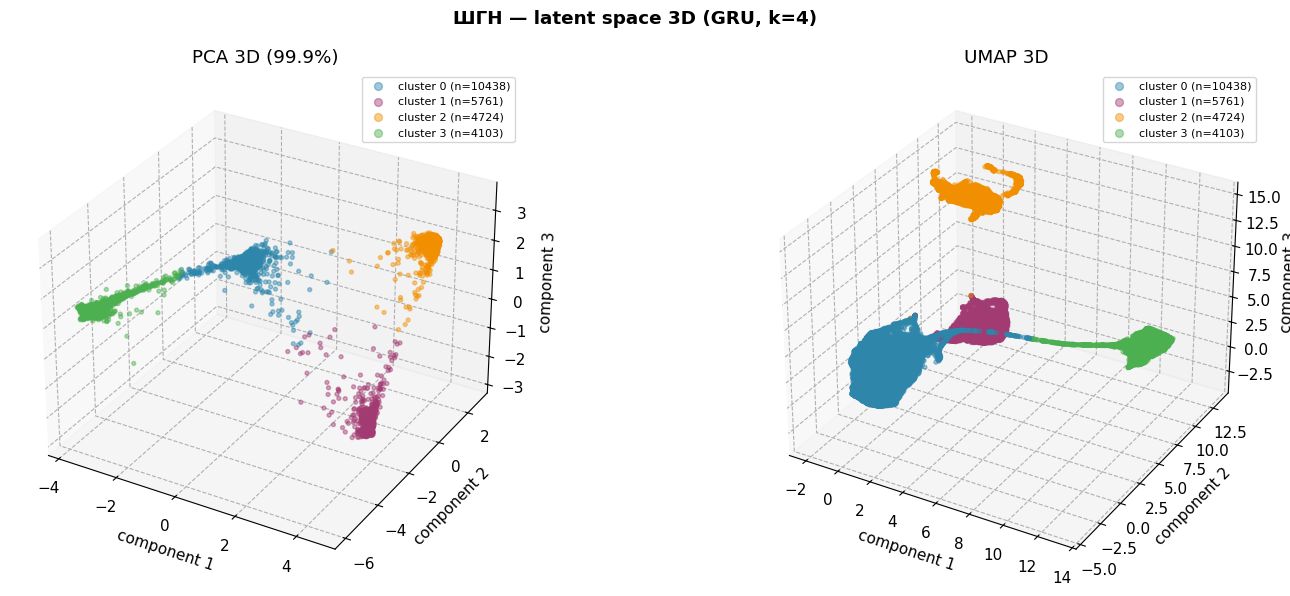

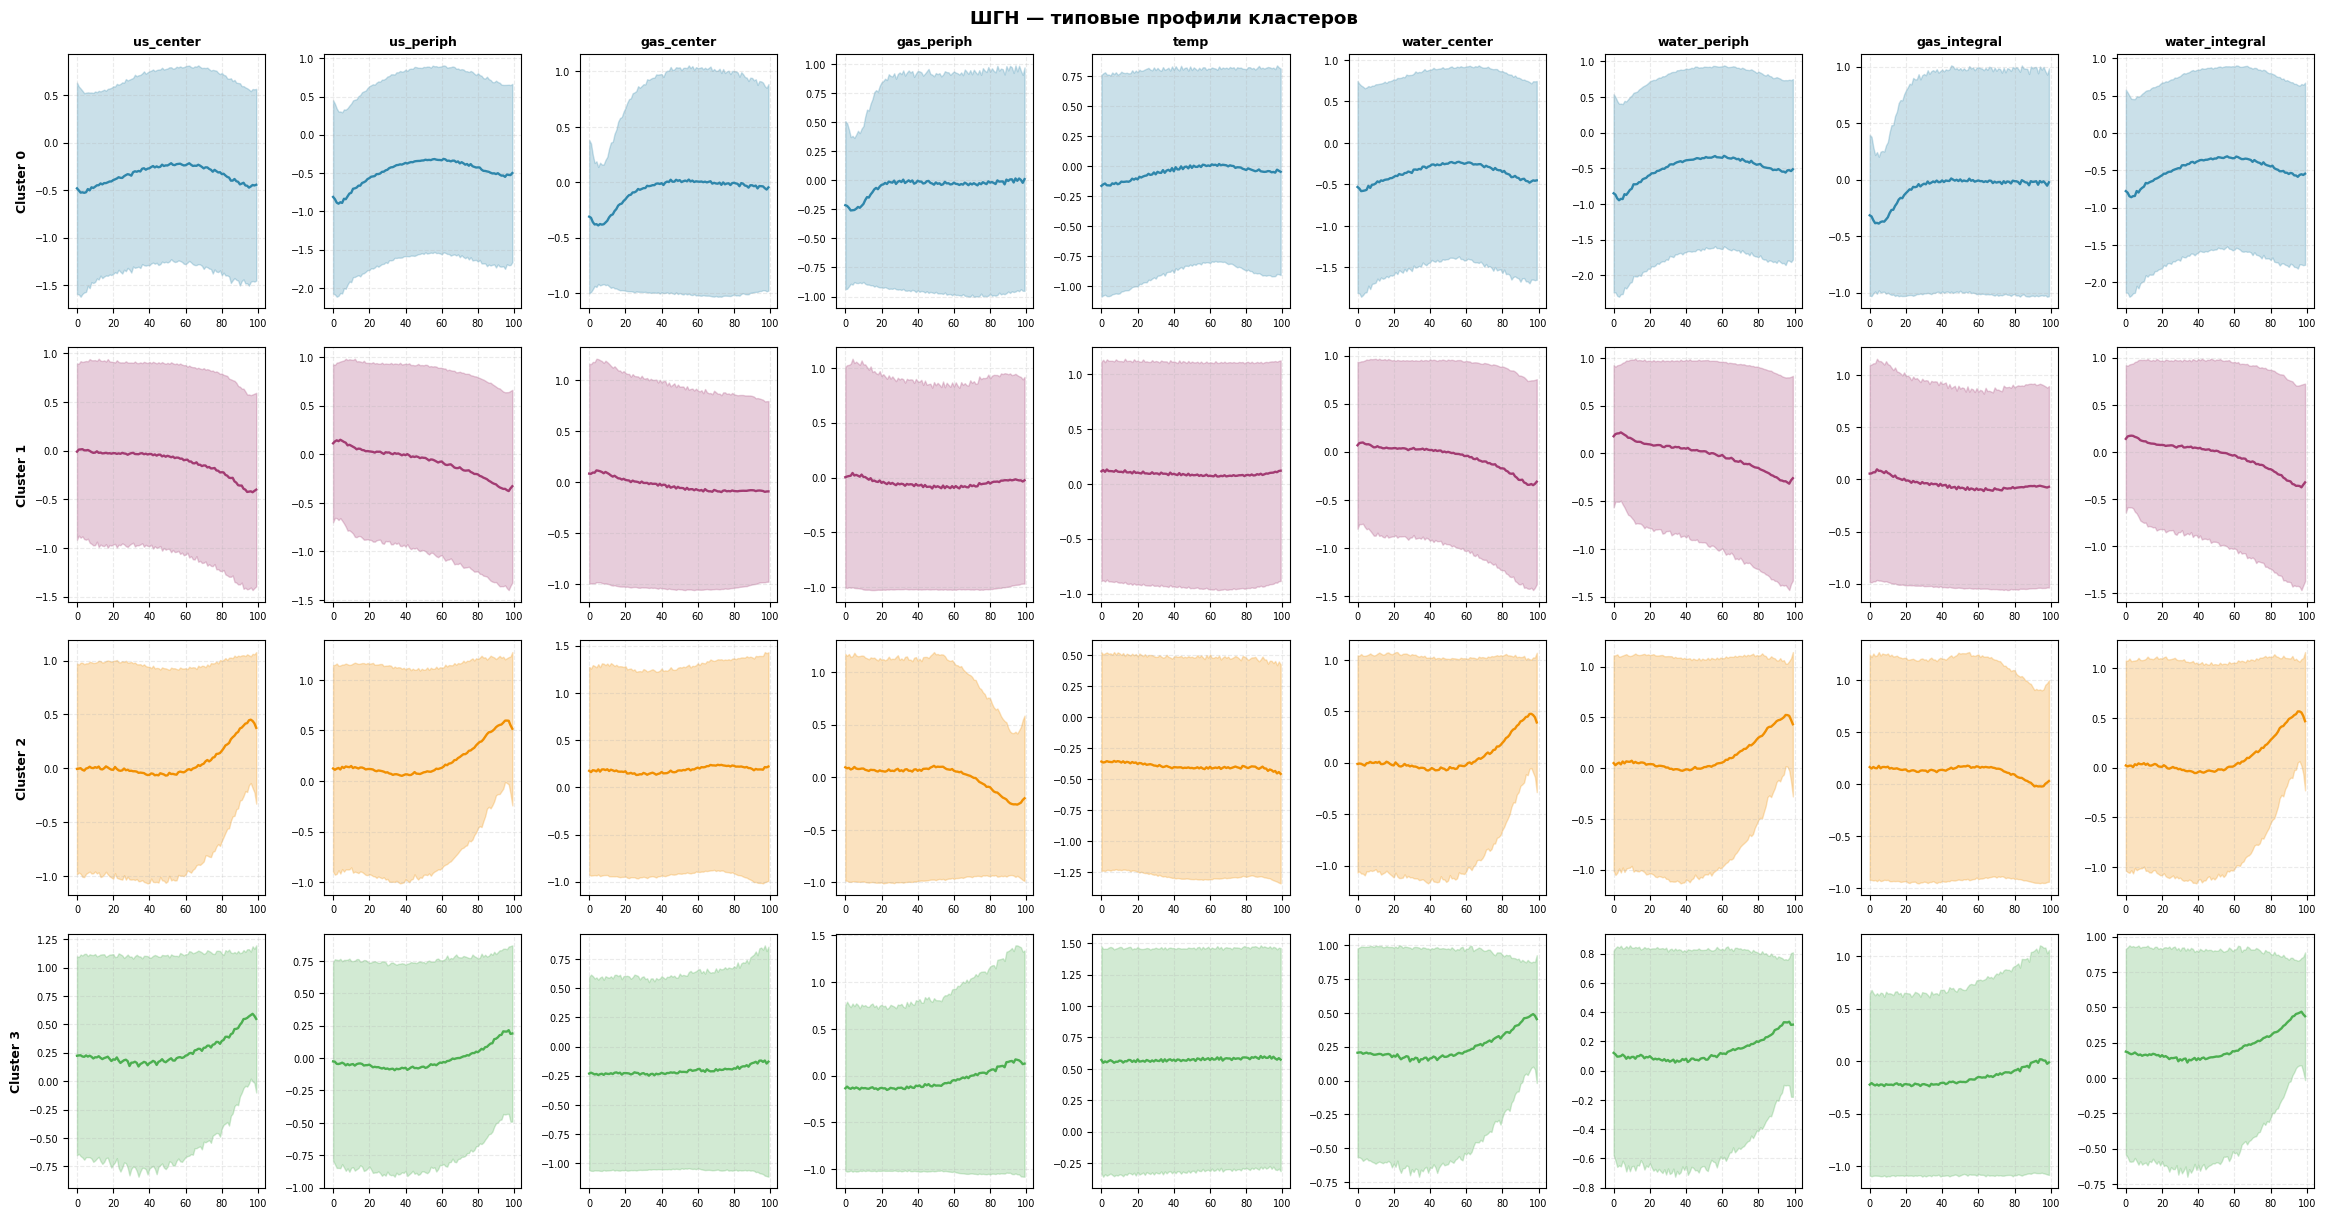

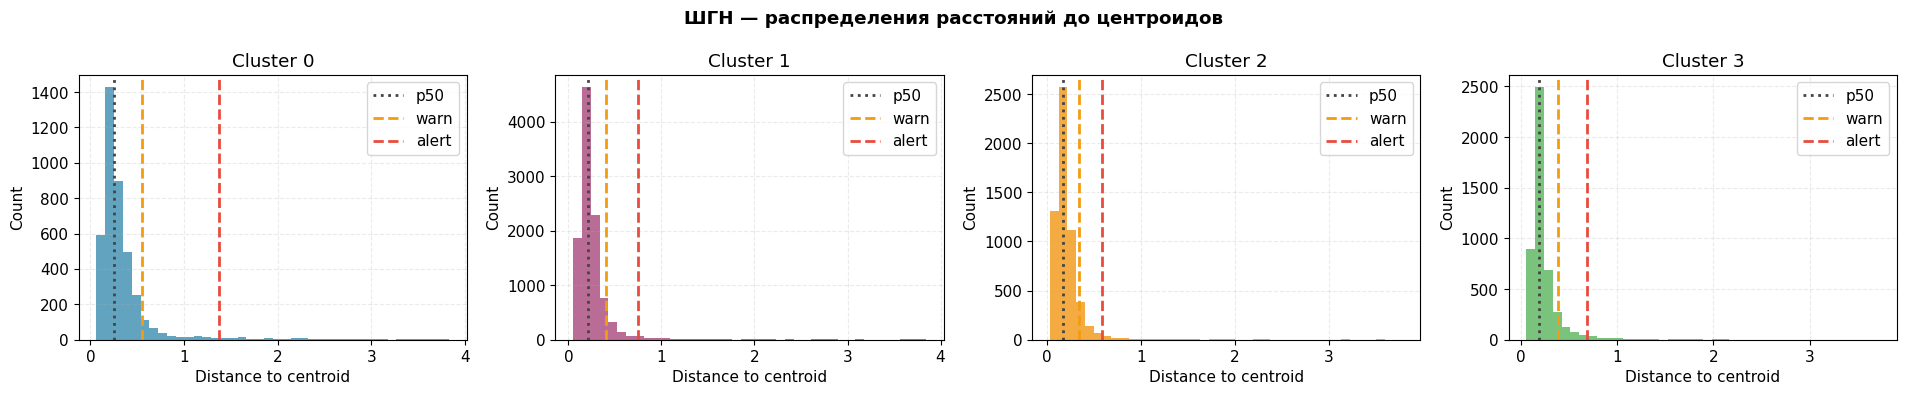

2026-05-13 20:36:54,704 | INFO | Pipeline finished for prefix=shgn


 cluster_id  n_cluster_windows  n_profile_windows  global_level  temporal_volatility  centroid_norm  distance_mean  distance_std
          0               4103               4103     -0.270520             1.061266       4.859255       0.360170      0.408029
          1              10438              10438     -0.038236             0.974791       8.048293       0.272613      0.301104
          2               5761               5761      0.053998             0.977675       7.606014       0.222283      0.247466
          3               4724               4724      0.112379             0.818246       6.487936       0.246022      0.221298

 cluster_id  n_cluster_windows  n_profile_windows  global_level  temporal_volatility  centroid_norm  distance_mean  distance_std activity_level stability_level     signature               top_positive_features                   top_negative_features                   top_variable_features
          0               4103               4103     -0.270520 

In [22]:
shgn_result = run_clustering_pipeline("shgn")

In [23]:
final_summary_df = pd.concat(
    [
        ecn_result["candidate_df"].assign(is_best=False),
        shgn_result["candidate_df"].assign(is_best=False),
    ],
    ignore_index=True,
)

In [24]:
best_pairs = {
    ("ecn", ecn_result["best_architecture"]),
    ("shgn", shgn_result["best_architecture"]),
}

final_summary_df["is_best"] = final_summary_df.apply(
    lambda row: (row["pump_type"], row["architecture"]) in best_pairs,
    axis=1,
)

final_summary_df = final_summary_df.sort_values(
    by=["pump_type", "is_best", "valid_by_size", "silhouette"],
    ascending=[True, False, False, False],
).reset_index(drop=True)

print(final_summary_df.to_string(index=False))

pump_type architecture  latent_dim  val_loss  test_loss  best_k  silhouette  davies_bouldin  calinski_harabasz  min_cluster_size  min_cluster_share  valid_by_size  selected  is_best
      ecn       Hybrid           8  0.019335   0.018038       4    0.611955        0.503425       5.766972e+03               317           0.115905           True      True     True
      ecn          GRU           8  0.019786   0.018218       4    0.547745        0.639376       3.837876e+03               343           0.125411           True     False    False
      ecn          TCN           8  0.017755   0.016886       2    0.854363        0.167647       1.821426e+03                25           0.009141          False     False    False
     shgn          GRU           8  0.182790   0.205540       4    0.939738        0.081537       1.109196e+06              4103           0.163949           True      True     True
     shgn       Hybrid           4  0.182069   0.203513       4    0.639283        0.46403